# TrafficLens: Data Lake Architecture

This notebook visualizes the data flow from raw video to Business Aggregates using the Medallion Architecture (Bronze ➜ Staging ➜ Curated).

## 1. Pipeline Flow Diagram

Run the code cell below to generate and display the architecture diagram.


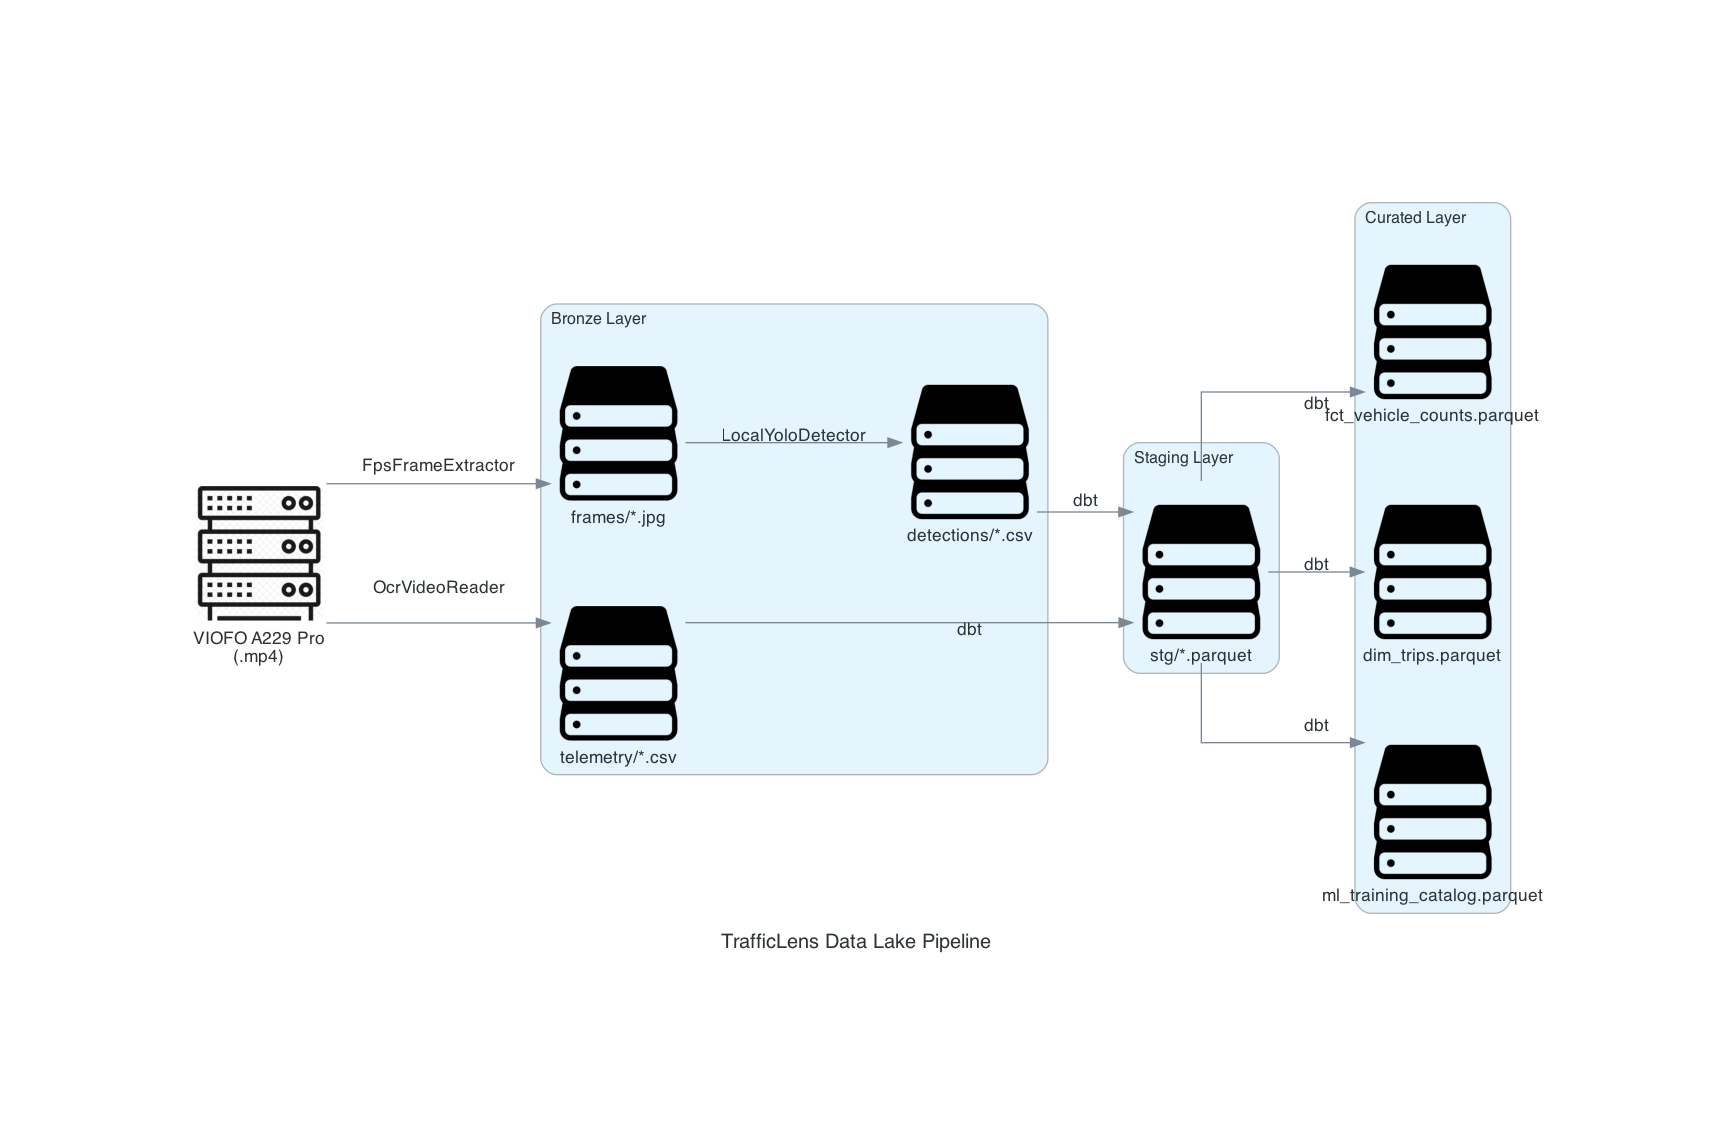

In [8]:
from diagrams import Diagram, Edge, Cluster
from diagrams.generic.storage import Storage
from diagrams.generic.compute import Rack
from IPython.display import Image

diagram_file = "/tmp/trafficlens_pipeline"

with Diagram("TrafficLens Data Lake Pipeline", filename=diagram_file, show=False, direction="LR"):
    video = Rack("VIOFO A229 Pro\n(.mp4)")

    with Cluster("Bronze Layer"):
        csv = Storage("telemetry/*.csv")
        img = Storage("frames/*.jpg")
        det = Storage("detections/*.csv")

    with Cluster("Staging Layer"):
        stg = Storage("stg/*.parquet")

    with Cluster("Curated Layer"):
        counts = Storage("fct_vehicle_counts.parquet")
        trips = Storage("dim_trips.parquet")
        ml = Storage("ml_training_catalog.parquet")

    video >> Edge(label="OcrVideoReader") >> csv
    video >> Edge(label="FpsFrameExtractor") >> img
    img >> Edge(label="LocalYoloDetector") >> det
    [csv, det] >> Edge(label="dbt") >> stg
    stg >> Edge(label="dbt") >> [counts, trips, ml]

Image(diagram_file + ".png")


---
## 2. OCR Image Processing — Bronze Layer

The `OcrVideoReader` extracts telemetry data from the dashcam video by cropping the bottom strip of each frame (where speed, GPS and timestamp are overlaid) and running Tesseract OCR on it.

Below are two real debug samples from a VIOFO A229 Pro frame:
- **Raw crop**: the bottom strip as-is from the video
- **Threshold crop**: after applying binary thresholding to improve OCR accuracy


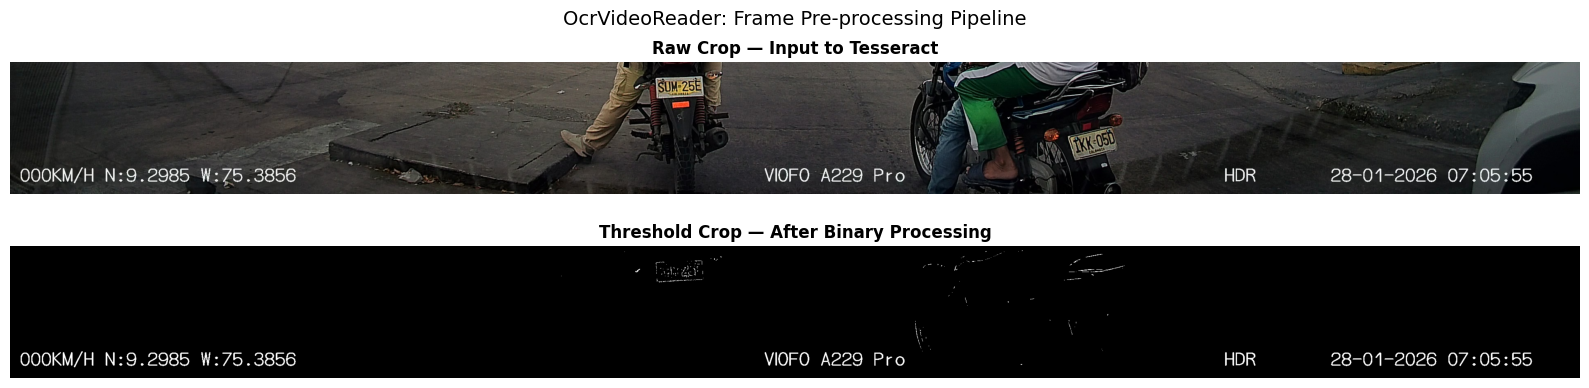

In [9]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

raw = mpimg.imread('debug_crop_raw.jpg')
thresh = mpimg.imread('debug_crop_thresh.jpg')

fig, axes = plt.subplots(2, 1, figsize=(16, 4))

axes[0].imshow(raw)
axes[0].set_title('Raw Crop — Input to Tesseract', fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(thresh, cmap='gray')
axes[1].set_title('Threshold Crop — After Binary Processing', fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.suptitle('OcrVideoReader: Frame Pre-processing Pipeline', fontsize=14, y=1.02)
plt.show()


---
## 2. Layer Details

### 🥉 Bronze — Raw Ingestion
- **Source**: VIOFO A229 Pro `.mp4` dashcam videos.
- **Process**: OCR extraction via `OcrVideoReader` (OpenCV + Tesseract).
- **Output**:
  - `datalake/bronze/telemetry/{video}.csv` — frame-by-frame telemetry.
  - `datalake/bronze/frames/{video}/*.jpg` — extracted frames at 1 FPS.
  - `datalake/bronze/detections/{video}/*.csv` — YOLO vehicle counts.

### 🥈 Staging — Cleaned & Typed
- **Process**: dbt + DuckDB (`stg_telemetry.sql`, `stg_detections.sql`).
- **Output**: `datalake/staging/{model}/partition_date=YYYY-MM-DD/*.parquet`
  - Timestamps → `DATETIME`, coordinates → `DOUBLE`, nulls removed.

### 🥇 Curated — Business Aggregates
- **`fct_vehicle_counts.parquet`**: Frame-level vehicle detection counts.
- **`dim_trips.parquet`**: Trip summary (`trip_id`, `start_time`, `duration`, `avg_speed`, `distance_km`).
- **`ml_training_catalog.parquet`**: High-quality frames for ML training (`speed > 5 km/h`).


In [10]:
# Example Data Interaction: Inspecting the Gold Layer
import duckdb
import pandas as pd

# Connect to DuckDB instance using our physical Path
conn = duckdb.connect(':memory:')

try:
    # Load business aggregate trips dataset
    df = conn.execute("SELECT * FROM '../datalake/gold/dim_trips.parquet' LIMIT 5").df()
    display(df)
except duckdb.BinderException:
    print("Run the ingestion and dbt pipeline first to populate the Gold layer!")

,trip_id,start_time,end_time,duration_seconds,avg_speed_kmh,max_speed_kmh,estimated_distance_km,total_points
0,/Users/anahiruiz/Documents/GitHub/trafficlens-...,2026-01-26 05:59:55,2026-01-26 06:00:47,52,1.264151,10.0,0.018260,53
1,/Users/anahiruiz/Documents/GitHub/trafficlens-...,2026-01-23 18:41:02,2026-01-23 18:46:01,299,12.880000,42.0,1.069756,300
2,/Users/anahiruiz/Documents/GitHub/trafficlens-...,2026-01-21 16:36:47,2026-01-21 16:41:46,299,11.688963,35.0,0.970833,299
3,/Users/anahiruiz/Documents/GitHub/trafficlens-...,2026-02-01 12:38:48,2026-02-01 12:38:50,2,0.000000,0.0,0.000000,3
4,/Users/anahiruiz/Documents/GitHub/trafficlens-...,2026-01-19 07:41:55,2026-01-19 07:43:41,106,0.186916,4.0,0.005504,107
